In [1]:
import pandas as pd, numpy as np, os
from db_queries import get_population, get_covariate_estimates, get_outputs, get_ids
import vivarium.artifact as art
from get_draws.api import get_draws
import matplotlib.pyplot as plt

In [3]:
location = 'nigeria'


l = get_ids('location')
location_id = l.loc[l.location_name==location.title()].location_id.values[0]
results_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_by_wealth_quintile/2026_08_13_13_55_48/0200_pregnancy_sim/sim_results/bouillon/nigeria/'
# results_dir = results_dir + location + '/'
# now get most recent timestep for specified location
# results_dir = results_dir + sorted(os.listdir(results_dir))[len(os.listdir(results_dir))-1] + '/results/'
# artifact_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/legacy_1.0/maternal/nigeria.hdf'
artifact_dir = f'/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_by_wealth_quintile/2026_08_13_13_55_48/0200_pregnancy_sim/mean_draw_artifacts/bouillon/nigeria.hdf'
results_dir

'/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_by_wealth_quintile/2026_08_13_13_55_48/0200_pregnancy_sim/sim_results/bouillon/nigeria/'

In [2]:
ls /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_by_wealth_quintile/2026_08_13_13_55_48/0200_pregnancy_sim/sim_results/bouillon/nigeria/

births.parquet
deaths.parquet
person_time_anemia.parquet
person_time_maternal_disorders.parquet
person_time_maternal_hemorrhage.parquet
person_time_pregnancy.parquet
pregnancy_outcome_count.parquet
transition_count_maternal_disorders.parquet
transition_count_maternal_hemorrhage.parquet
transition_count_pregnancy.parquet
ylds.parquet
ylls.parquet


# First, load artifact

In [4]:
art = art.Artifact(artifact_dir, filter_terms=['sex==Female','age_start>5','age_end<=60'])

In [5]:
def add_age_group(data):
    data = data.copy() if 'age_start' in data.columns else data.reset_index()
    data['age_group'] = (data.age_start.astype(int).astype(str)
                         + '_to_' + (data.age_end.astype(int) - 1).astype(str))
    return data

In [6]:
art.keys

['metadata.keyspace',
 'metadata.locations',
 'population.location',
 'population.structure',
 'population.age_bins',
 'population.demographic_dimensions',
 'population.theoretical_minimum_risk_life_expectancy',
 'population.infant_male_percentage',
 'population.wealth_quintile_probabilities',
 'vehicle.name',
 'covariate.age_specific_fertility_rate.estimate',
 'covariate.stillbirth_to_live_birth_ratio.estimate',
 'cause.maternal_abortion_and_miscarriage.raw_incidence_rate',
 'cause.ectopic_pregnancy.raw_incidence_rate',
 'risk_factor.low_birth_weight_and_short_gestation.exposure',
 'risk_factor.low_birth_weight_and_short_gestation.distribution',
 'risk_factor.low_birth_weight_and_short_gestation.categories',
 'cause.maternal_disorders.raw_incidence_rate',
 'cause.maternal_disorders.incident_probability',
 'cause.maternal_disorders.cause_specific_mortality_rate',
 'cause.maternal_disorders.mortality_probability',
 'cause.maternal_disorders.ylds',
 'risk_factor.hemoglobin_on_maternal_di

In [7]:
# load up pregnancy incidence
# equations found here: https://vivarium-research.readthedocs.io/en/latest/models/other_models/pregnancy/gbd_2021_closed_cohort/index.html
asfr = art.load('covariate.age_specific_fertility_rate.estimate')
sbr = art.load('covariate.stillbirth_to_live_birth_ratio.estimate') 
inc_mis = art.load('cause.maternal_abortion_and_miscarriage.raw_incidence_rate')
inc_ect = art.load('cause.ectopic_pregnancy.raw_incidence_rate')
art_preg_inc = (asfr 
               + asfr * sbr.value.values[0]
               + inc_mis 
               + inc_ect)
art_preg_inc.head()

draw_0
sex    age_start age_end year_start year_end          
Female 10.0      15.0    2021       2022      0.003739
       15.0      20.0    2021       2022      0.101765
       20.0      25.0    2021       2022      0.254821
       25.0      30.0    2021       2022      0.279212
       30.0      35.0    2021       2022      0.258735

In [8]:
# load artifact MD data
art_md_mort = art.load('cause.maternal_disorders.cause_specific_mortality_rate')
art_mort_frac = art_md_mort / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_mort_frac.head()

draw_0
sex    age_start age_end year_start year_end            
Female 10.0      15.0    2021       2022      447.401788
       15.0      20.0    2021       2022      259.218555
       20.0      25.0    2021       2022      156.962792
       25.0      30.0    2021       2022      164.397846
       30.0      35.0    2021       2022      209.120594

In [9]:
# load artifact MD data
art_md_inc = art.load('cause.maternal_disorders.raw_incidence_rate')
art_mh_inc = art.load('cause.maternal_hemorrhage.raw_incidence_rate')
art_inc_frac = art_md_inc / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_mh_frac = art_mh_inc / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_inc_frac#.head()

draw_0
sex    age_start age_end year_start year_end              
Female 10.0      15.0    2021       2022      25676.584912
       15.0      20.0    2021       2022      62026.963776
       20.0      25.0    2021       2022      54584.963267
       25.0      30.0    2021       2022      56992.993879
       30.0      35.0    2021       2022      61415.182469
       35.0      40.0    2021       2022      63855.030690
       40.0      45.0    2021       2022      69860.354852
       45.0      50.0    2021       2022      59081.027501
       50.0      55.0    2021       2022      84068.727859
       55.0      60.0    2021       2022               NaN

In [10]:
art_mh_frac
    # zeros for 50-55 year olds

draw_0
sex    age_start age_end year_start year_end              
Female 10.0      15.0    2021       2022       3579.141522
       15.0      20.0    2021       2022       9318.703576
       20.0      25.0    2021       2022       8307.772565
       25.0      30.0    2021       2022       9033.277055
       30.0      35.0    2021       2022      10263.079065
       35.0      40.0    2021       2022      11028.515827
       40.0      45.0    2021       2022      13164.553145
       45.0      50.0    2021       2022      12306.234002
       50.0      55.0    2021       2022      14828.611379
       55.0      60.0    2021       2022               NaN

# Now, load sim data

In [12]:
deaths = pd.read_parquet(results_dir + 'deaths.parquet')
deaths = deaths.loc[deaths.entity == 'maternal_disorders']
deaths.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,random_seed,input_draw,value
0,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,1,intervention,9,0,0.0
2,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,2,intervention,9,0,0.0
4,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,3,intervention,9,0,0.0
6,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,4,intervention,9,0,0.0
8,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,5,intervention,9,0,0.0


In [ ]:
# assert deaths.entity.unique() == ['maternal_disorders'], "deaths data has more causes than maternal disorders which is the only expected cause"

In [14]:
md_inc = pd.read_parquet(results_dir + 'transition_count_maternal_disorders.parquet')
md_inc = md_inc.loc[md_inc.sub_entity=='susceptible_to_maternal_disorders_to_maternal_disorders']
md_inc = (md_inc.groupby(['scenario','input_draw','age_group'])['value'].sum()
          + deaths.groupby(['scenario','input_draw','age_group'])['value'].sum()
         ).reset_index() 
# note that incident cases are only counted among surviving simulants, so we add in deaths here
md_inc.head()

,scenario,input_draw,age_group,value
0,baseline,0,10_to_14,629.0
1,baseline,0,15_to_19,43172.0
2,baseline,0,20_to_24,93067.0
3,baseline,0,25_to_29,93809.0
4,baseline,0,30_to_34,76670.0


In [15]:
mh_inc = pd.read_parquet(results_dir + 'transition_count_maternal_hemorrhage.parquet')
mh_inc = mh_inc.loc[mh_inc.sub_entity=='susceptible_to_maternal_hemorrhage_to_maternal_hemorrhage']
mh_inc.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,random_seed,input_draw,value
0,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,1,intervention,9,0,0.0
1,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,2,intervention,9,0,0.0
2,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,3,intervention,9,0,0.0
3,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,4,intervention,9,0,0.0
4,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,5,intervention,9,0,0.0


In [16]:
births = pd.read_parquet(results_dir + 'transition_count_pregnancy.parquet')
births = births.loc[births.sub_entity=='pregnant_to_parturition']
# add in deaths because they are not getting tracked in the parturition transition counts
births = (births.groupby(['scenario','input_draw','age_group'])['value'].sum()
          + deaths.groupby(['scenario','input_draw','age_group'])['value'].sum()).reset_index()
births.head()

,scenario,input_draw,age_group,value
0,baseline,0,10_to_14,1553.0
1,baseline,0,15_to_19,55006.0
2,baseline,0,20_to_24,128299.0
3,baseline,0,25_to_29,126240.0
4,baseline,0,30_to_34,96525.0


In [17]:
births.loc[births.scenario=='baseline'].groupby('input_draw')['value'].sum().unique()

array([500000.])

In [18]:
n_simulants_per_draw = 500_000
assert births.loc[births.scenario=='baseline'].groupby('input_draw')['value'].sum().unique() == [n_simulants_per_draw], "Number of births does not match expected number of simulants"

In [19]:
cols = ['scenario','input_draw','age_group']
mort_frac_births = ((deaths.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                    .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
inc_frac_births = ((md_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                    .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
mh_frac_births = ((mh_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                     .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
mort_frac_births.head()

/tmp/ipykernel_758093/3074800288.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mort_frac_births = ((deaths.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
/tmp/ipykernel_758093/3074800288.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mh_frac_births = ((mh_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)


count        mean  std         min        2.5%  \
scenario age_group                                                   
baseline 10_to_14     1.0  579.523503  NaN  579.523503  579.523503   
         15_to_19     1.0  327.237029  NaN  327.237029  327.237029   
         20_to_24     1.0  219.799063  NaN  219.799063  219.799063   
         25_to_29     1.0  230.513308  NaN  230.513308  230.513308   
         30_to_34     1.0  267.288267  NaN  267.288267  267.288267   

                           50%       97.5%         max  
scenario age_group                                      
baseline 10_to_14   579.523503  579.523503  579.523503  
         15_to_19   327.237029  327.237029  327.237029  
         20_to_24   219.799063  219.799063  219.799063  
         25_to_29   230.513308  230.513308  230.513308  
         30_to_34   267.288267  267.288267  267.288267

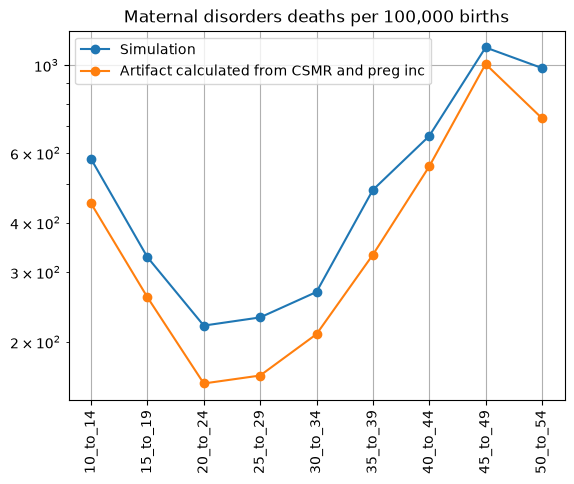

In [20]:
sim = mort_frac_births.reset_index().loc[mort_frac_births.reset_index().scenario
                                        =='baseline']

plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_mort_frac[[c for c in art_mort_frac.columns if int(c.split('_')[1]) in deaths.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact calculated from CSMR and preg inc')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal disorders deaths per 100,000 births')
plt.semilogy()
plt.show()
# a little off in our edge age groups but otherwise looking good

In [21]:
deaths = deaths.loc[deaths.entity=='maternal_disorders']
deaths = deaths.groupby(['age_group','scenario','input_draw'])['value'].sum().reset_index()
deaths = deaths.groupby(['age_group','scenario'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
deaths.head()

,age_group,scenario,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,baseline,1.0,9.0,NaN,9.0,9.0,9.0,9.0,9.0
1,10_to_14,intervention,1.0,9.0,NaN,9.0,9.0,9.0,9.0,9.0
2,10_to_14,zero,1.0,9.0,NaN,9.0,9.0,9.0,9.0,9.0
3,15_to_19,baseline,1.0,180.0,NaN,180.0,180.0,180.0,180.0,180.0
4,15_to_19,intervention,1.0,174.0,NaN,174.0,174.0,174.0,174.0,174.0


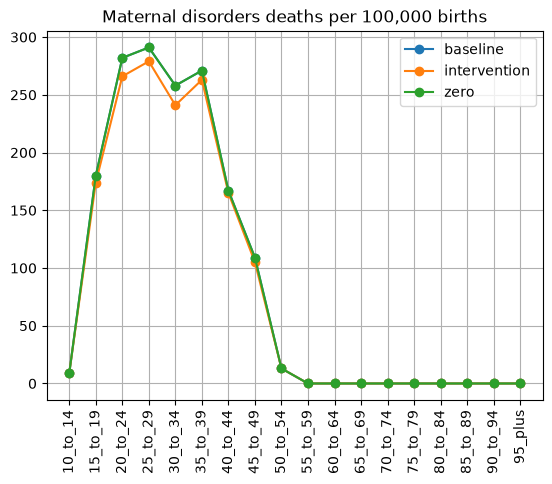

In [22]:
for scenario in deaths.scenario.unique(): 
    sim = deaths.loc[deaths.scenario==scenario]
    plt.plot(sim.age_group, sim['mean'], marker='o', label=scenario)
    #plt.fill_between(sim.age, sim['2.5%'], sim['97.5%'], alpha=0.2)

plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal disorders deaths per 100,000 births')
#plt.semilogy()
plt.show()

# ok this looks as expected!
# zero coverage should be the highest, followed by baseline
# then the remaining scenarios should all overlap below baseline

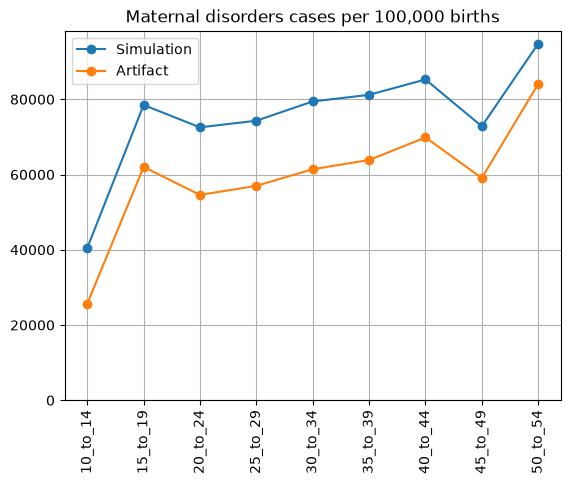

In [23]:
sim = inc_frac_births.reset_index().loc[inc_frac_births.reset_index().scenario
                                        =='baseline']
plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_inc_frac[[c for c in art_inc_frac.columns if int(c.split('_')[1]) in mh_inc.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.ylim(ymin=0)
plt.title('Maternal disorders cases per 100,000 births')
plt.show()

# it's looking a little high... what if we don't add in deaths?

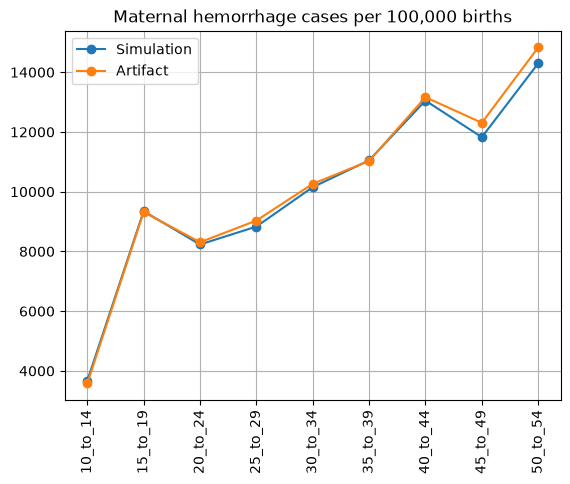

In [24]:
sim = mh_frac_births.reset_index().loc[mh_frac_births.reset_index().scenario
                                        =='baseline']

plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_mh_frac#[[c for c in art_mh_frac.columns if int(c.split('_')[1]) in mh_inc.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal hemorrhage cases per 100,000 births')
plt.show()

In [25]:
preg_inc = art_preg_inc.reset_index()
preg_inc['age_group'] = (preg_inc.age_start.astype(int).astype(str) + '_to_' + (preg_inc.age_end.astype(int)-1).astype(str))
preg_inc = preg_inc.set_index('age_group')[[c for c in preg_inc.columns if 'draw' in c]]
preg_inc = preg_inc.stack().reset_index().rename(columns={'level_1':'input_draw',0:'value'})
preg_inc['input_draw'] = preg_inc.input_draw.str.split('_', expand=True)[1].astype(int)
preg_inc = preg_inc.set_index(['age_group','input_draw'])
preg_inc

,,value
age_group,input_draw,
10_to_14,0,0.003739
15_to_19,0,0.101765
20_to_24,0,0.254821
25_to_29,0,0.279212
30_to_34,0,0.258735
35_to_39,0,0.175389
40_to_44,0,0.092934
45_to_49,0,0.042190
50_to_54,0,0.004798


In [27]:
# what about YLDs?
ylds = pd.read_parquet(results_dir + 'ylds.parquet')
ylds_per_birth = (ylds.groupby(cols + ['entity']).sum() / births.groupby(cols).sum())[['value']]
yld_rate = (ylds_per_birth.reset_index().set_index(['age_group','input_draw','scenario','entity']) * preg_inc).dropna()
yld_rate = yld_rate.groupby([c for c in cols if c != 'input_draw'] + ['entity'])['value'].describe(percentiles=[0.025,0.975])
ylds

/tmp/ipykernel_758093/1225580331.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ylds_per_birth = (ylds.groupby(cols + ['entity']).sum() / births.groupby(cols).sum())[['value']]


,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,random_seed,input_draw,value
0,ylds,cause,all_causes,all_causes,10_to_14,invalid,1,intervention,9,0,1.111376
1,ylds,cause,pregnancy,pregnant,10_to_14,invalid,1,intervention,9,0,0.000000
2,ylds,cause,pregnancy,parturition,10_to_14,invalid,1,intervention,9,0,0.000000
3,ylds,cause,pregnancy,postpartum,10_to_14,invalid,1,intervention,9,0,0.000000
4,ylds,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,1,intervention,9,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
94495,ylds,cause,pregnancy,parturition,95_plus,severe,5,baseline,4,0,0.000000
94496,ylds,cause,pregnancy,postpartum,95_plus,severe,5,baseline,4,0,0.000000
94497,ylds,cause,maternal_disorders,maternal_disorders,95_plus,severe,5,baseline,4,0,0.000000
94498,ylds,cause,maternal_hemorrhage,maternal_hemorrhage,95_plus,severe,5,baseline,4,0,0.000000


In [28]:
YEAR_START = 2021 
gbd_ylds = get_draws(release_id=9,
                    year_id=YEAR_START, 
                    source='como',
                    gbd_id_type='cause_id',
                    gbd_id=366,
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
gbd_ylds

/ihme/homes/lutzes/.conda/envs/vivarium_gates_nutrition_optimization_artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


,year_id,sex_id,age_group_id,measure_id,cause_id,draw_0,draw_1,draw_2,draw_3,draw_4,...,draw_493,draw_494,draw_495,draw_496,draw_497,draw_498,draw_499,location_id,metric_id,version_id
0,2021,2,7,3,366,0.000008,0.000006,0.000006,0.000009,0.000007,...,0.000008,0.000009,0.000009,0.000006,0.000011,0.000008,0.000011,214,3,1471
1,2021,2,8,3,366,0.000481,0.000310,0.000371,0.000455,0.000389,...,0.000465,0.000680,0.000598,0.000309,0.000675,0.000486,0.000576,214,3,1471
2,2021,2,9,3,366,0.001512,0.001061,0.001143,0.001301,0.001137,...,0.001382,0.001788,0.001638,0.000992,0.002004,0.001335,0.001531,214,3,1471
3,2021,2,10,3,366,0.002436,0.001914,0.001767,0.002479,0.001980,...,0.002054,0.002206,0.002282,0.001470,0.002946,0.002500,0.002735,214,3,1471
4,2021,2,11,3,366,0.003114,0.002559,0.002492,0.003200,0.002750,...,0.002469,0.002728,0.003065,0.001862,0.003581,0.004034,0.003652,214,3,1471
5,2021,2,12,3,366,0.002791,0.002355,0.002159,0.002670,0.002625,...,0.002118,0.002618,0.002744,0.001805,0.003352,0.003886,0.003324,214,3,1471
6,2021,2,13,3,366,0.002089,0.001868,0.001672,0.002000,0.001969,...,0.001556,0.002015,0.002021,0.001422,0.002535,0.002905,0.002647,214,3,1471
7,2021,2,14,3,366,0.001441,0.001257,0.001208,0.001253,0.001419,...,0.001045,0.001516,0.001344,0.001043,0.001590,0.002128,0.001827,214,3,1471
8,2021,2,15,3,366,0.000988,0.000852,0.000773,0.000809,0.000919,...,0.000670,0.001053,0.000900,0.000715,0.001075,0.001408,0.001191,214,3,1471


In [29]:
# MD anemia YLDs
from db_queries import get_ids
x = get_draws(release_id=9,
                    year_id=YEAR_START,
                    source='como',
                    gbd_id_type='sequela_id',
                    gbd_id=[182,183,184],
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
x = x.merge(get_ids('age_group'), on='age_group_id')
x['age_start'] = x.age_group_name.str.split(' to ', expand=True)[0].astype(float)
x['age_end'] = x.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
x['sex'] = 'Female'
x = x.groupby(['sex','age_start','age_end',])[[c for c in x.columns if 'draw' in c]].sum()
x

/ihme/homes/lutzes/.conda/envs/vivarium_gates_nutrition_optimization_artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


draw_0        draw_1    draw_2    draw_3  \
sex    age_start age_end                                               
Female 10.0      15.0     0.000001  7.757562e-07  0.000001  0.000002   
       15.0      20.0     0.000063  4.238768e-05  0.000073  0.000136   
       20.0      25.0     0.000180  1.141321e-04  0.000162  0.000262   
       25.0      30.0     0.000230  1.768203e-04  0.000188  0.000395   
       30.0      35.0     0.000243  2.133146e-04  0.000189  0.000487   
       35.0      40.0     0.000176  1.142510e-04  0.000122  0.000386   
       40.0      45.0     0.000089  9.073427e-05  0.000077  0.000241   
       45.0      50.0     0.000025  3.026184e-05  0.000024  0.000084   
       50.0      55.0     0.000006  4.450655e-06  0.000003  0.000010   

                            draw_4    draw_5        draw_6    draw_7  \
sex    age_start age_end                                               
Female 10.0      15.0     0.000001  0.000002  8.548040e-07  0.000003   
       15.0      20.0     0.000062  0.000102  6.003513e-05  0.000161   
       20.0      25.0     0.000134  0.000236  1.386914e-04  0.000290   
       25.0      30.0     0.000182  0.000217  1.817432e-04  0.000279   
       30.0      35.0     0.000208  0.000303  1.809014e-04  0.000248   
       35.0      40.0     0.000124  0.000307  1.157717e-04  0.000139   
       40.0      45.0     0.000111  0.000166  5.860877e-05  0.000071   
       45.0      50.0     0.000050  0.000064  2.115965e-05  0.000033   
       50.0      55.0     0.000006  0.000008  3.436110e-06  0.000005   

                                draw_8    draw_9  ...  draw_490  draw_491  \
sex    age_start age_end                          ...                       
Female 10.0      15.0     8.195313e-07  0.000002  ...  0.000002  0.000001   
       15.0      20.0     5.554020e-05  0.000107  ...  0.000093  0.000111   
       20.0      25.0     1.213275e-04  0.000192  ...  0.000179  0.000223   
       25.0      30.0     1.519877e-04  0.000213  ...  0.000219  0.000201   
       30.0      35.0     1.530025e-04  0.000264  ...  0.000301  0.000212   
       35.0      40.0     9.112101e-05  0.000175  ...  0.000303  0.000182   
       40.0      45.0     6.318983e-05  0.000148  ...  0.000165  0.000094   
       45.0      50.0     3.284879e-05  0.000046  ...  0.000036  0.000037   
       50.0      55.0     4.669700e-06  0.000012  ...  0.000008  0.000009   

                          draw_492  draw_493  draw_494  draw_495  draw_496  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000002  0.000001  0.000001  0.000002  0.000001   
       15.0      20.0     0.000051  0.000116  0.000155  0.000086  0.000066   
       20.0      25.0     0.000118  0.000193  0.000351  0.000167  0.000129   
       25.0      30.0     0.000176  0.000192  0.000338  0.000166  0.000162   
       30.0      35.0     0.000173  0.000173  0.000287  0.000253  0.000169   
       35.0      40.0     0.000138  0.000118  0.000188  0.000209  0.000133   
       40.0      45.0     0.000077  0.000097  0.000099  0.000128  0.000098   
       45.0      50.0     0.000023  0.000058  0.000027  0.000044  0.000033   
       50.0      55.0     0.000004  0.000010  0.000006  0.000009  0.000007   

                          draw_497  draw_498  draw_499  
sex    age_start age_end                                
Female 10.0      15.0     0.000003  0.000002  0.000002  
       15.0      20.0     0.000124  0.000083  0.000103  
       20.0      25.0     0.000202  0.000219  0.000254  
       25.0      30.0     0.000240  0.000242  0.000279  
       30.0      35.0     0.000356  0.000241  0.000362  
       35.0      40.0     0.000306  0.000122  0.000287  
       40.0      45.0     0.000157  0.000100  0.000200  
       45.0      50.0     0.000040  0.000049  0.000086  
       50.0      55.0     0.000006  0.000008  0.000013  

[9 rows x 500 columns]

In [30]:
# MD YLDs prepped
y = gbd_ylds.merge(get_ids('age_group'), on='age_group_id')
y['age_start'] = y.age_group_name.str.split(' to ', expand=True)[0].astype(float)
y['age_end'] = y.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
y['sex'] = 'Female'
y = y.set_index(['sex','age_start','age_end'])[[c for c in y.columns if 'draw' in c]]
y

draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000008  0.000006  0.000006  0.000009  0.000007   
       15.0      20.0     0.000481  0.000310  0.000371  0.000455  0.000389   
       20.0      25.0     0.001512  0.001061  0.001143  0.001301  0.001137   
       25.0      30.0     0.002436  0.001914  0.001767  0.002479  0.001980   
       30.0      35.0     0.003114  0.002559  0.002492  0.003200  0.002750   
       35.0      40.0     0.002791  0.002355  0.002159  0.002670  0.002625   
       40.0      45.0     0.002089  0.001868  0.001672  0.002000  0.001969   
       45.0      50.0     0.001441  0.001257  0.001208  0.001253  0.001419   
       50.0      55.0     0.000988  0.000852  0.000773  0.000809  0.000919   

                            draw_5    draw_6    draw_7    draw_8    draw_9  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000009  0.000006  0.000009  0.000006  0.000008   
       15.0      20.0     0.000539  0.000369  0.000654  0.000354  0.000436   
       20.0      25.0     0.001609  0.001039  0.001759  0.001073  0.001198   
       25.0      30.0     0.002230  0.001800  0.002272  0.001631  0.001935   
       30.0      35.0     0.002706  0.002523  0.002525  0.002052  0.002702   
       35.0      40.0     0.002459  0.002418  0.002182  0.001861  0.002593   
       40.0      45.0     0.001845  0.001977  0.001621  0.001466  0.001964   
       45.0      50.0     0.001311  0.001507  0.001124  0.001058  0.001413   
       50.0      55.0     0.000796  0.001078  0.000714  0.000707  0.000980   

                          ...  draw_490  draw_491  draw_492  draw_493  \
sex    age_start age_end  ...                                           
Female 10.0      15.0     ...  0.000011  0.000010  0.000006  0.000008   
       15.0      20.0     ...  0.000677  0.000653  0.000280  0.000465   
       20.0      25.0     ...  0.001999  0.001477  0.000891  0.001382   
       25.0      30.0     ...  0.002807  0.001987  0.001641  0.002054   
       30.0      35.0     ...  0.003164  0.002465  0.002308  0.002469   
       35.0      40.0     ...  0.002603  0.002052  0.002154  0.002118   
       40.0      45.0     ...  0.001760  0.001587  0.001524  0.001556   
       45.0      50.0     ...  0.001182  0.001159  0.001087  0.001045   
       50.0      55.0     ...  0.000778  0.000742  0.000700  0.000670   

                          draw_494  draw_495  draw_496  draw_497  draw_498  \
sex    age_start age_end                                                     
Female 10.0      15.0     0.000009  0.000009  0.000006  0.000011  0.000008   
       15.0      20.0     0.000680  0.000598  0.000309  0.000675  0.000486   
       20.0      25.0     0.001788  0.001638  0.000992  0.002004  0.001335   
       25.0      30.0     0.002206  0.002282  0.001470  0.002946  0.002500   
       30.0      35.0     0.002728  0.003065  0.001862  0.003581  0.004034   
       35.0      40.0     0.002618  0.002744  0.001805  0.003352  0.003886   
       40.0      45.0     0.002015  0.002021  0.001422  0.002535  0.002905   
       45.0      50.0     0.001516  0.001344  0.001043  0.001590  0.002128   
       50.0      55.0     0.001053  0.000900  0.000715  0.001075  0.001408   

                          draw_499  
sex    age_start age_end            
Female 10.0      15.0     0.000011  
       15.0      20.0     0.000576  
       20.0      25.0     0.001531  
       25.0      30.0     0.002735  
       30.0      35.0     0.003652  
       35.0      40.0     0.003324  
       40.0      45.0     0.002647  
       45.0      50.0     0.001827  
       50.0      55.0     0.001191  

[9 rows x 500 columns]

In [31]:
from db_queries import get_ids
g = y - x
g = g.reset_index().set_index(['age_start'])[[c for c in g.columns if 'draw' in c
                                and int(c.split('_')[1]) in ylds.input_draw.unique()]]
g = g.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
g

,age_start,count,mean,std,min,2.5%,50%,97.5%,max
0,10.0,1.0,0.000007,NaN,0.000007,0.000007,0.000007,0.000007,0.000007
1,15.0,1.0,0.000418,NaN,0.000418,0.000418,0.000418,0.000418,0.000418
2,20.0,1.0,0.001333,NaN,0.001333,0.001333,0.001333,0.001333,0.001333
3,25.0,1.0,0.002206,NaN,0.002206,0.002206,0.002206,0.002206,0.002206
4,30.0,1.0,0.002870,NaN,0.002870,0.002870,0.002870,0.002870,0.002870
5,35.0,1.0,0.002615,NaN,0.002615,0.002615,0.002615,0.002615,0.002615
6,40.0,1.0,0.002000,NaN,0.002000,0.002000,0.002000,0.002000,0.002000
7,45.0,1.0,0.001415,NaN,0.001415,0.001415,0.001415,0.001415,0.001415
8,50.0,1.0,0.000982,NaN,0.000982,0.000982,0.000982,0.000982,0.000982


In [32]:
md_ylds = yld_rate.copy().reset_index()
# md_ylds = md_ylds.loc[(md_ylds.entity=='maternal_disorders')
#                      &(md_ylds.scenario=='baseline')]
md_ylds

,scenario,age_group,entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,all_causes,1.0,1.521823e-04,NaN,1.521823e-04,1.521823e-04,1.521823e-04,1.521823e-04,1.521823e-04
1,baseline,10_to_14,anemia,1.0,1.521598e-04,NaN,1.521598e-04,1.521598e-04,1.521598e-04,1.521598e-04,1.521598e-04
2,baseline,10_to_14,maternal_disorders,1.0,2.252652e-08,NaN,2.252652e-08,2.252652e-08,2.252652e-08,2.252652e-08,2.252652e-08
3,baseline,10_to_14,maternal_hemorrhage,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,baseline,10_to_14,pregnancy,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
130,zero,50_to_54,all_causes,1.0,5.933347e-05,NaN,5.933347e-05,5.933347e-05,5.933347e-05,5.933347e-05,5.933347e-05
131,zero,50_to_54,anemia,1.0,5.723423e-05,NaN,5.723423e-05,5.723423e-05,5.723423e-05,5.723423e-05,5.723423e-05
132,zero,50_to_54,maternal_disorders,1.0,2.099243e-06,NaN,2.099243e-06,2.099243e-06,2.099243e-06,2.099243e-06,2.099243e-06
133,zero,50_to_54,maternal_hemorrhage,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


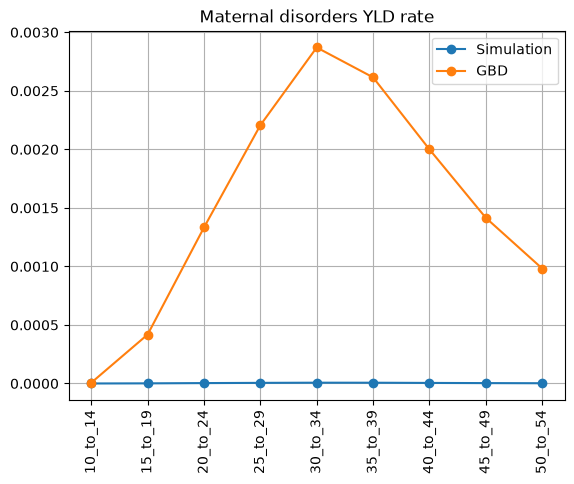

In [33]:
md_ylds = yld_rate.copy().reset_index()
md_ylds = md_ylds.loc[(md_ylds.entity=='maternal_disorders')
                     &(md_ylds.scenario=='baseline')]
plt.plot(md_ylds.reset_index().age_group, md_ylds['mean'], marker='o', label='Simulation')
plt.fill_between(md_ylds.age_group, md_ylds['2.5%'], md_ylds['97.5%'], alpha=0.3)
plt.plot(md_ylds.age_group, g['mean'], marker='o', label='GBD')
plt.fill_between(md_ylds.age_group, g['2.5%'], g['97.5%'], alpha=0.3)
#plt.semilogy()
plt.xticks(rotation=90)
plt.legend()
plt.title('Maternal disorders YLD rate')
plt.grid()

/tmp/ipykernel_758093/1912319701.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mort_frac= (deaths.groupby(cols).sum() / births.groupby(cols).sum())[['value']]


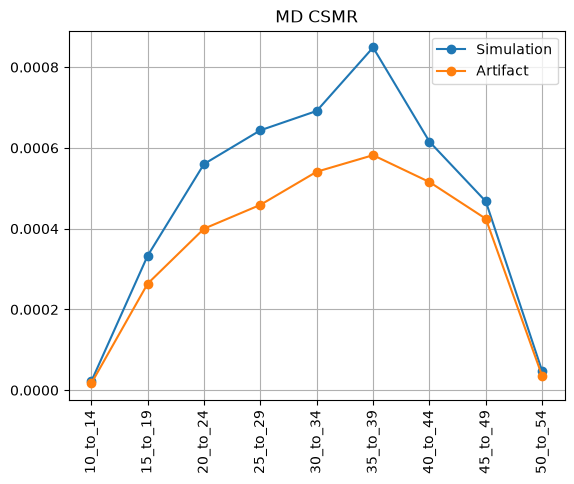

In [35]:
cols = ['scenario','input_draw','age_group']
deaths = pd.read_parquet(results_dir + 'deaths.parquet')
mort_frac= (deaths.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (mort_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_disorders.cause_specific_mortality_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in ylds.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MD CSMR')
plt.grid()
plt.legend()

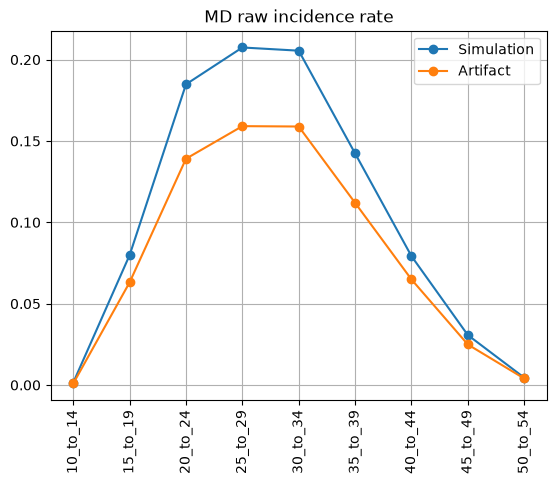

In [36]:
cols = ['scenario','input_draw','age_group']
inc_frac= (md_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (inc_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_disorders.raw_incidence_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in ylds.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MD raw incidence rate')
plt.grid()
plt.legend()

/tmp/ipykernel_758093/3920017641.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  inc_frac= (mh_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]


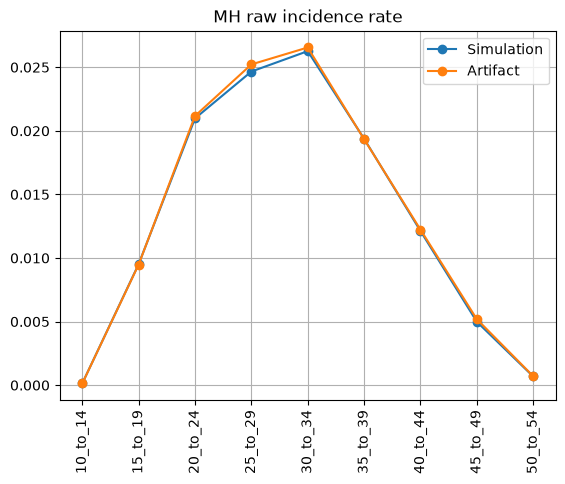

In [37]:
cols = ['scenario','input_draw','age_group']
inc_frac= (mh_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (inc_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_hemorrhage.raw_incidence_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in deaths.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MH raw incidence rate')
plt.grid()
plt.legend()

# Checking more artifact values

In [38]:
# MD anemia YLDs

x = get_draws(release_id=9,
                    year_id=YEAR_START,
                    source='como',
                    gbd_id_type='sequela_id',
                    gbd_id=[182,183,184],
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
x = x.merge(get_ids('age_group'), on='age_group_id')
x['age_start'] = x.age_group_name.str.split(' to ', expand=True)[0].astype(float)
x['age_end'] = x.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
x['sex'] = 'Female'
x['year_start'] = YEAR_START # UPDATE?
x['year_end'] = YEAR_START + 1 # UPDATE?
x = x.groupby(['sex','age_start','age_end','year_start','year_end'])[[c for c in x.columns if 'draw' in c]].sum()
x

/ihme/homes/lutzes/.conda/envs/vivarium_gates_nutrition_optimization_artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


draw_0        draw_1  \
sex    age_start age_end year_start year_end                           
Female 10.0      15.0    2021       2022      0.000001  7.757562e-07   
       15.0      20.0    2021       2022      0.000063  4.238768e-05   
       20.0      25.0    2021       2022      0.000180  1.141321e-04   
       25.0      30.0    2021       2022      0.000230  1.768203e-04   
       30.0      35.0    2021       2022      0.000243  2.133146e-04   
       35.0      40.0    2021       2022      0.000176  1.142510e-04   
       40.0      45.0    2021       2022      0.000089  9.073427e-05   
       45.0      50.0    2021       2022      0.000025  3.026184e-05   
       50.0      55.0    2021       2022      0.000006  4.450655e-06   

                                                draw_2    draw_3    draw_4  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2021       2022      0.000001  0.000002  0.000001   
       15.0      20.0    2021       2022      0.000073  0.000136  0.000062   
       20.0      25.0    2021       2022      0.000162  0.000262  0.000134   
       25.0      30.0    2021       2022      0.000188  0.000395  0.000182   
       30.0      35.0    2021       2022      0.000189  0.000487  0.000208   
       35.0      40.0    2021       2022      0.000122  0.000386  0.000124   
       40.0      45.0    2021       2022      0.000077  0.000241  0.000111   
       45.0      50.0    2021       2022      0.000024  0.000084  0.000050   
       50.0      55.0    2021       2022      0.000003  0.000010  0.000006   

                                                draw_5        draw_6  \
sex    age_start age_end year_start year_end                           
Female 10.0      15.0    2021       2022      0.000002  8.548040e-07   
       15.0      20.0    2021       2022      0.000102  6.003513e-05   
       20.0      25.0    2021       2022      0.000236  1.386914e-04   
       25.0      30.0    2021       2022      0.000217  1.817432e-04   
       30.0      35.0    2021       2022      0.000303  1.809014e-04   
       35.0      40.0    2021       2022      0.000307  1.157717e-04   
       40.0      45.0    2021       2022      0.000166  5.860877e-05   
       45.0      50.0    2021       2022      0.000064  2.115965e-05   
       50.0      55.0    2021       2022      0.000008  3.436110e-06   

                                                draw_7        draw_8  \
sex    age_start age_end year_start year_end                           
Female 10.0      15.0    2021       2022      0.000003  8.195313e-07   
       15.0      20.0    2021       2022      0.000161  5.554020e-05   
       20.0      25.0    2021       2022      0.000290  1.213275e-04   
       25.0      30.0    2021       2022      0.000279  1.519877e-04   
       30.0      35.0    2021       2022      0.000248  1.530025e-04   
       35.0      40.0    2021       2022      0.000139  9.112101e-05   
       40.0      45.0    2021       2022      0.000071  6.318983e-05   
       45.0      50.0    2021       2022      0.000033  3.284879e-05   
       50.0      55.0    2021       2022      0.000005  4.669700e-06   

                                                draw_9  ...  draw_490  \
sex    age_start age_end year_start year_end            ...             
Female 10.0      15.0    2021       2022      0.000002  ...  0.000002   
       15.0      20.0    2021       2022      0.000107  ...  0.000093   
       20.0      25.0    2021       2022      0.000192  ...  0.000179   
       25.0      30.0    2021       2022      0.000213  ...  0.000219   
       30.0      35.0    2021       2022      0.000264  ...  0.000301   
       35.0      40.0    2021       2022      0.000175  ...  0.000303   
       40.0      45.0    2021       2022      0.000148  ...  0.000165   
       45.0      50.0    2021       2022      0.000046  ...  0.000036   
       50.0      55.0    2021       2022      0.000012  ...  0.000008   

      

In [39]:
# MD YLDs prepped
y = gbd_ylds.merge(get_ids('age_group'), on='age_group_id')
y['age_start'] = y.age_group_name.str.split(' to ', expand=True)[0].astype(float)
y['age_end'] = y.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
y['sex'] = 'Female'
y['year_start'] = YEAR_START
y['year_end'] = YEAR_START + 1
y = y.set_index(['sex','age_start','age_end','year_start','year_end'])[[c for c in y.columns if 'draw' in c]]
y

draw_0    draw_1    draw_2  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2021       2022      0.000008  0.000006  0.000006   
       15.0      20.0    2021       2022      0.000481  0.000310  0.000371   
       20.0      25.0    2021       2022      0.001512  0.001061  0.001143   
       25.0      30.0    2021       2022      0.002436  0.001914  0.001767   
       30.0      35.0    2021       2022      0.003114  0.002559  0.002492   
       35.0      40.0    2021       2022      0.002791  0.002355  0.002159   
       40.0      45.0    2021       2022      0.002089  0.001868  0.001672   
       45.0      50.0    2021       2022      0.001441  0.001257  0.001208   
       50.0      55.0    2021       2022      0.000988  0.000852  0.000773   

                                                draw_3    draw_4    draw_5  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2021       2022      0.000009  0.000007  0.000009   
       15.0      20.0    2021       2022      0.000455  0.000389  0.000539   
       20.0      25.0    2021       2022      0.001301  0.001137  0.001609   
       25.0      30.0    2021       2022      0.002479  0.001980  0.002230   
       30.0      35.0    2021       2022      0.003200  0.002750  0.002706   
       35.0      40.0    2021       2022      0.002670  0.002625  0.002459   
       40.0      45.0    2021       2022      0.002000  0.001969  0.001845   
       45.0      50.0    2021       2022      0.001253  0.001419  0.001311   
       50.0      55.0    2021       2022      0.000809  0.000919  0.000796   

                                                draw_6    draw_7    draw_8  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2021       2022      0.000006  0.000009  0.000006   
       15.0      20.0    2021       2022      0.000369  0.000654  0.000354   
       20.0      25.0    2021       2022      0.001039  0.001759  0.001073   
       25.0      30.0    2021       2022      0.001800  0.002272  0.001631   
       30.0      35.0    2021       2022      0.002523  0.002525  0.002052   
       35.0      40.0    2021       2022      0.002418  0.002182  0.001861   
       40.0      45.0    2021       2022      0.001977  0.001621  0.001466   
       45.0      50.0    2021       2022      0.001507  0.001124  0.001058   
       50.0      55.0    2021       2022      0.001078  0.000714  0.000707   

                                                draw_9  ...  draw_490  \
sex    age_start age_end year_start year_end            ...             
Female 10.0      15.0    2021       2022      0.000008  ...  0.000011   
       15.0      20.0    2021       2022      0.000436  ...  0.000677   
       20.0      25.0    2021       2022      0.001198  ...  0.001999   
       25.0      30.0    2021       2022      0.001935  ...  0.002807   
       30.0      35.0    2021       2022      0.002702  ...  0.003164   
       35.0      40.0    2021       2022      0.002593  ...  0.002603   
       40.0      45.0    2021       2022      0.001964  ...  0.001760   
       45.0      50.0    2021       2022      0.001413  ...  0.001182   
       50.0      55.0    2021       2022      0.000980  ...  0.000778   

                                              draw_491  draw_492  draw_493  \
sex    age_start age_end year_start year_end                                 
Female 10.0      15.0    2021       2022      0.000010  0.000006  0.000008   
       15.0      20.0    2021       2022      0.000653  0.000280  0.000465   
       20.0      25.0    2021       2022      0.001477  0.000891  0.001382   
       25.0      30.0    2021       2022      0.001987  0.001641  0.002054   
       30.0      35.0    2021       2022      0.002465  0.002308  0.002469   
       35.0      40.0    2021       2022      0.002052  0.002154  0.002118   
       40.0      45.0    2021       2022   

In [40]:
calculated_ylds  = ((y-x)/( art.load('cause.maternal_disorders.raw_incidence_rate') - art.load('cause.maternal_disorders.cause_specific_mortality_rate'))).mean(axis=1).reset_index()
calculated_ylds

,sex,age_start,age_end,year_start,year_end,0
0,Female,10.0,15.0,2021,2022,0.006892
1,Female,15.0,20.0,2021,2022,0.006651
2,Female,20.0,25.0,2021,2022,0.009609
3,Female,25.0,30.0,2021,2022,0.013904
4,Female,30.0,35.0,2021,2022,0.018125
5,Female,35.0,40.0,2021,2022,0.023472
6,Female,40.0,45.0,2021,2022,0.031050
7,Female,45.0,50.0,2021,2022,0.057765
8,Female,50.0,55.0,2021,2022,0.245654
9,Female,55.0,60.0,2021,2022,NaN


In [41]:
art_ylds = art.load('cause.maternal_disorders.ylds')
art_ylds = art_ylds.mean(axis=1).reset_index()
art_ylds

,sex,age_start,age_end,year_start,year_end,0
0,Female,10.0,15.0,2021,2022,0.000015
1,Female,15.0,20.0,2021,2022,0.000014
2,Female,20.0,25.0,2021,2022,0.000018
3,Female,25.0,30.0,2021,2022,0.000025
4,Female,30.0,35.0,2021,2022,0.000033
5,Female,35.0,40.0,2021,2022,0.000046
6,Female,40.0,45.0,2021,2022,0.000060
7,Female,45.0,50.0,2021,2022,0.000108
8,Female,50.0,55.0,2021,2022,0.000466
9,Female,55.0,60.0,2021,2022,0.000277


Text(0.5, 1.0, 'Maternal disorders YLDs per non-fatal case')

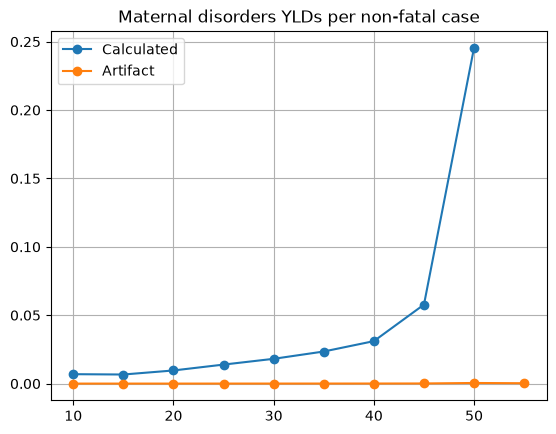

In [42]:
plt.plot(calculated_ylds.age_start, calculated_ylds[0], marker='o', label='Calculated')
plt.plot(art_ylds.age_start, art_ylds[0], marker='o', label='Artifact')
plt.legend()
#plt.semilogy()
plt.grid()
plt.title('Maternal disorders YLDs per non-fatal case')

In [43]:
gbd_csmr = get_outputs(release_id=9,
                    year_id=YEAR_START,
                    sex_id=2,
                    age_group_id=list(range(7,17)),
                    topic='cause',
                    cause_id=366,
                    measure_id=1,
                    metric_id=3,
                    location_id=location_id,
                    #compare_version_id=7948
                      )
gbd_csmr

,age_group_id,cause_id,location_id,measure_id,metric_id,sex_id,year_id,acause,age_group_name,cause_name,expected,location_name,location_type,measure,measure_name,metric_name,sex,val,upper,lower
0,7,366,214,1,3,2,2021,maternal,10 to 14,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000017,0.000031,0.000008
1,8,366,214,1,3,2,2021,maternal,15 to 19,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000264,0.000385,0.000172
2,9,366,214,1,3,2,2021,maternal,20 to 24,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000400,0.000624,0.000240
3,10,366,214,1,3,2,2021,maternal,25 to 29,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000459,0.000711,0.000285
4,11,366,214,1,3,2,2021,maternal,30 to 34,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000541,0.000811,0.000355
5,12,366,214,1,3,2,2021,maternal,35 to 39,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000582,0.000854,0.000383
6,13,366,214,1,3,2,2021,maternal,40 to 44,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000516,0.000774,0.000333
7,14,366,214,1,3,2,2021,maternal,45 to 49,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000425,0.000673,0.000241
8,15,366,214,1,3,2,2021,maternal,50 to 54,Maternal disorders,False,Nigeria,admin0,death,Deaths,Rate,Female,0.000035,0.000066,0.000017
9,16,366,214,1,3,2,2021,maternal,55 to 59,Maternal disorders,NaN,Nigeria,admin0,death,Deaths,Rate,Female,NaN,NaN,NaN


Text(0.5, 1.0, 'MD CSMR')

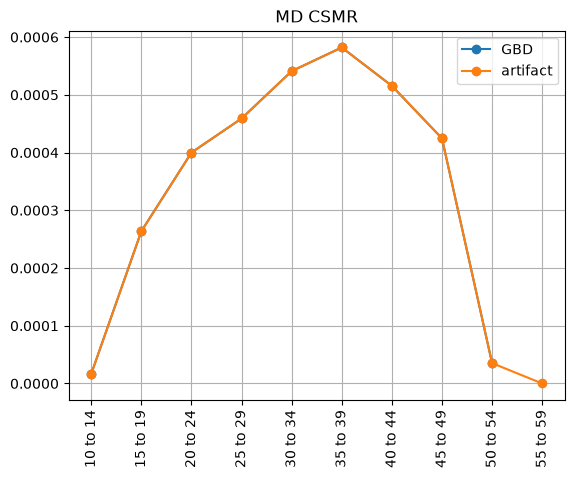

In [44]:
plt.plot(gbd_csmr.age_group_name, gbd_csmr.val, marker='o', label='GBD')
plt.plot(gbd_csmr.age_group_name, art.load('cause.maternal_disorders.cause_specific_mortality_rate').mean(axis=1),
        marker='o', label="artifact")
plt.grid()
plt.xticks(rotation=90)
plt.legend()
plt.title('MD CSMR')

    # These used to exactly replicate eachother... double check year_ids

In [46]:
anemia_pt = pd.read_parquet(results_dir + 'person_time_anemia.parquet')
anemia_pt = anemia_pt.loc[anemia_pt.scenario=='baseline']
anemia_pt.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,random_seed,input_draw,value
12600,person_time,impairment,anemia,not_anemic,10_to_14,invalid,1,baseline,7,0,4.522930
12601,person_time,impairment,anemia,not_anemic,10_to_14,invalid,2,baseline,7,0,7.091034
12602,person_time,impairment,anemia,not_anemic,10_to_14,invalid,3,baseline,7,0,7.646817
12603,person_time,impairment,anemia,not_anemic,10_to_14,invalid,4,baseline,7,0,8.279261
12604,person_time,impairment,anemia,not_anemic,10_to_14,invalid,5,baseline,7,0,8.394251


In [47]:
(anemia_pt.groupby(['scenario','sub_entity'])['value'].sum() 
 / anemia_pt.groupby(['scenario'])['value'].sum()).reset_index().sort_values(by='sub_entity').dropna()

,scenario,sub_entity,value
0,baseline,mild,0.252493
1,baseline,moderate,0.280061
2,baseline,not_anemic,0.451680
3,baseline,severe,0.015766


In [48]:
cols = ['input_draw','scenario','age_group']
anemia = (anemia_pt.groupby(cols + ['sub_entity'])['value'].sum() 
          / anemia_pt.groupby(cols)['value'].sum()).reset_index().dropna()
anemia = (anemia.groupby([c for c in cols if c != 'input_draw'] + ['sub_entity'])
          ['value'].describe(percentiles=[0.025,0.975]).reset_index())
anemia.head()

,scenario,age_group,sub_entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,mild,1.0,0.124274,NaN,0.124274,0.124274,0.124274,0.124274,0.124274
1,baseline,10_to_14,moderate,1.0,0.523558,NaN,0.523558,0.523558,0.523558,0.523558,0.523558
2,baseline,10_to_14,not_anemic,1.0,0.277257,NaN,0.277257,0.277257,0.277257,0.277257,0.277257
3,baseline,10_to_14,severe,1.0,0.074911,NaN,0.074911,0.074911,0.074911,0.074911,0.074911
4,baseline,15_to_19,mild,1.0,0.242446,NaN,0.242446,0.242446,0.242446,0.242446,0.242446


In [49]:
target = pd.read_pickle('../../data_prep/hgb_validation_targets/validation_target_wra_weighted_by_draw')
target = target.loc[(target.parent_id==location_id)
                   &(target.draw.isin([f'draw_{x}' for x in ylds.input_draw.unique()]))
                   &(target.population=='pregnant')]
target['dw'] = np.where(target.severity=='severe', 0.149,
                       np.where(target.severity=='moderate', 0.052,
                               np.where(target.severity=='mild', 0.004, 0)))
target['ylds'] = target['value'] * target.dw
target = target.merge(get_ids('age_group'), on='age_group_id')
target['age_group'] = target.age_group_name.str.replace(' ', '_')

target_prev = target.groupby(['age_group','severity'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
target_yld = target.groupby(['age_group','draw']).ylds.sum().groupby('age_group').describe(percentiles=[0.025,0.975]).reset_index()
target_yld.head()

,age_group,count,mean,std,min,2.5%,50%,97.5%,max
0,15_to_19,1.0,0.017838,NaN,0.017838,0.017838,0.017838,0.017838,0.017838
1,20_to_24,1.0,0.016458,NaN,0.016458,0.016458,0.016458,0.016458,0.016458
2,25_to_29,1.0,0.016444,NaN,0.016444,0.016444,0.016444,0.016444,0.016444
3,30_to_34,1.0,0.018657,NaN,0.018657,0.018657,0.018657,0.018657,0.018657
4,35_to_39,1.0,0.017085,NaN,0.017085,0.017085,0.017085,0.017085,0.017085


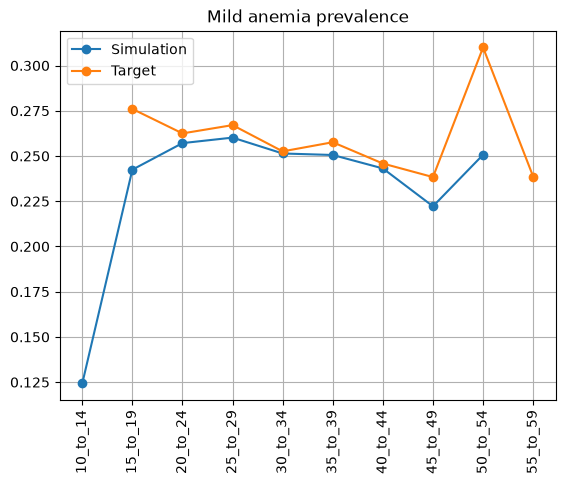

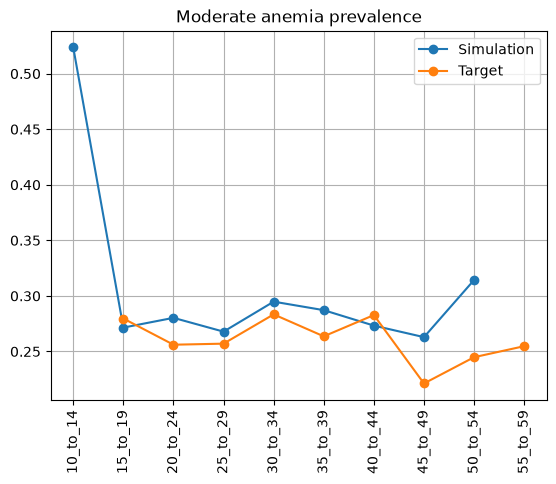

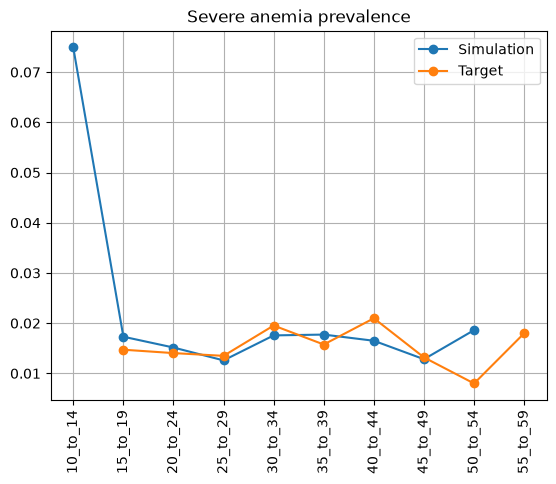

In [50]:
for sev in ['mild','moderate','severe']:
    s = anemia.loc[anemia.sub_entity==sev]
    plt.plot(s.age_group, s['mean'], marker='o', label='Simulation')
    plt.fill_between(s.age_group, s['2.5%'], s['97.5%'], alpha=0.2)
    t = target_prev.loc[target_prev.severity==sev]
    plt.plot(t.age_group, t['mean'], marker='o', label='Target')
    plt.fill_between(t.age_group, t['2.5%'], t['97.5%'], alpha=0.2)
    plt.grid()
    plt.legend()
    plt.xticks(rotation=90)
    plt.title(f'{sev.title()} anemia prevalence')
    plt.show()

In [52]:
anemia_ylds = ylds.loc[(ylds.sub_entity=='anemia')&(ylds.scenario=='baseline')]
pt = pd.read_parquet(results_dir + 'person_time_pregnancy.parquet')
pt = pt.loc[pt.scenario=='baseline']
anemia_ylds = (anemia_ylds.groupby(['input_draw','age_group']).sum()[['value']] 
               / pt.groupby(['input_draw','age_group']).sum()[['value']]
               #* (52/36)
              )
anemia_ylds = anemia_ylds.groupby(['age_group']).value.describe(percentiles=[0.025,0.975]).reset_index()
anemia_ylds = anemia_ylds.fillna(0)
anemia_ylds

/tmp/ipykernel_758093/2070876972.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  anemia_ylds = (anemia_ylds.groupby(['input_draw','age_group']).sum()[['value']]
/tmp/ipykernel_758093/2070876972.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  / pt.groupby(['input_draw','age_group']).sum()[['value']]


,age_group,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,1.0,0.038173,0.0,0.038173,0.038173,0.038173,0.038173,0.038173
1,15_to_19,1.0,0.017233,0.0,0.017233,0.017233,0.017233,0.017233,0.017233
2,20_to_24,1.0,0.017410,0.0,0.017410,0.017410,0.017410,0.017410,0.017410
3,25_to_29,1.0,0.016400,0.0,0.016400,0.016400,0.016400,0.016400,0.016400
4,30_to_34,1.0,0.018448,0.0,0.018448,0.018448,0.018448,0.018448,0.018448
5,35_to_39,1.0,0.018072,0.0,0.018072,0.018072,0.018072,0.018072,0.018072
6,40_to_44,1.0,0.017140,0.0,0.017140,0.017140,0.017140,0.017140,0.017140
7,45_to_49,1.0,0.016020,0.0,0.016020,0.016020,0.016020,0.016020,0.016020
8,50_to_54,1.0,0.019435,0.0,0.019435,0.019435,0.019435,0.019435,0.019435
9,55_to_59,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Anemia YLD rate')

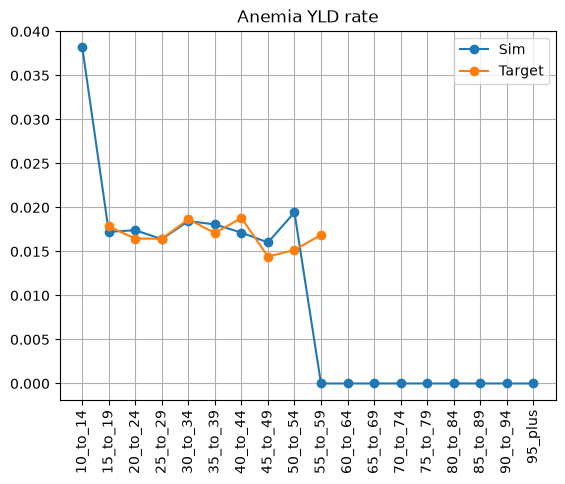

In [53]:
plt.plot(anemia_ylds.age_group, anemia_ylds['mean'], marker='o', label='Sim')
plt.fill_between(anemia_ylds.age_group, anemia_ylds['2.5%'], anemia_ylds['97.5%'], alpha=0.2)
plt.plot(target_yld.age_group, target_yld['mean'], marker='o', label='Target')
plt.fill_between(target_yld.age_group, target_yld['2.5%'], target_yld['97.5%'], alpha=0.2)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
#plt.ylim(ymax=0.05)
plt.title('Anemia YLD rate')

# ok this used to be meeting target in model 12.0 but looks off here